In [3]:
#Homework 8
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

In [2]:
import numpy as np
import tensorflow as tf

print(np.__version__)
print(tf.__version__)

1.23.5
2.10.0


In [4]:
N_sin = 10000
N_sample = 100
np.random.seed(42)

t = np.linspace(0, 4 * np.pi, N_sample)  
A = np.random.uniform(0.5, 1.5, size=(N_sin, 1))      
omega = np.random.uniform(0.5, 2.0, size=(N_sin, 1))  
phi = np.random.uniform(0, 2 * np.pi, size=(N_sin, 1))

clean_curve = A * np.sin(omega * t + phi)

# Add Gaussian noise (sigma = 0.2)
sigma = 0.2
noise = np.random.normal(0, sigma, size=(N_sin, N_sample))

noisy_curve = clean_curve + noise

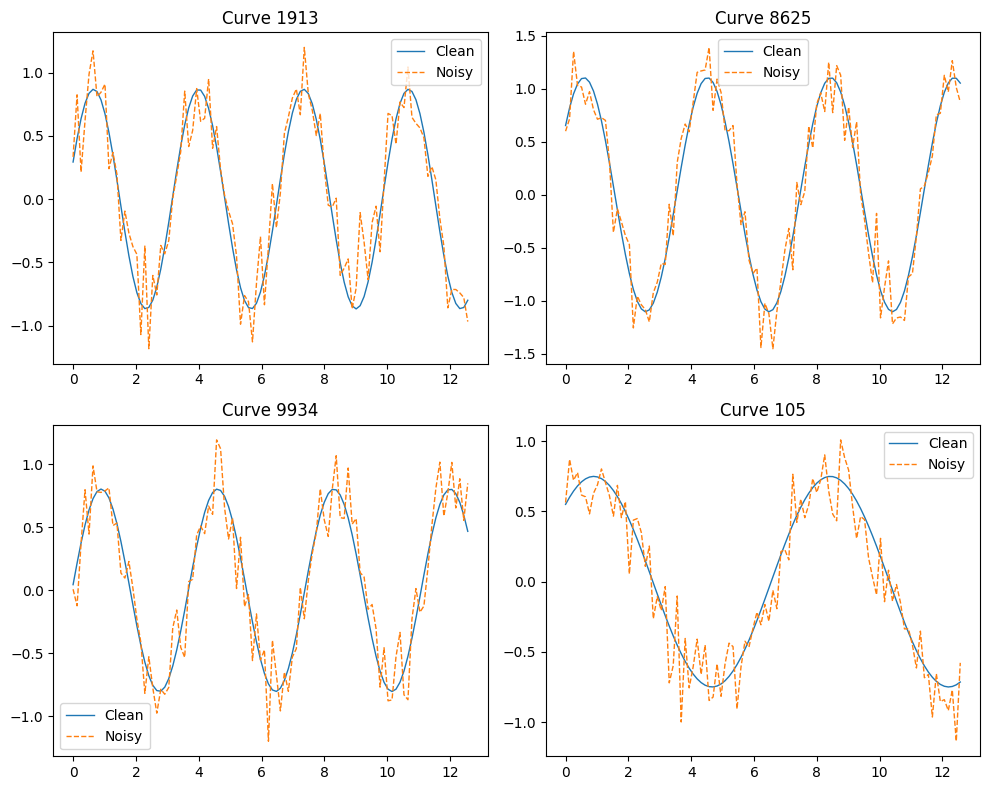

In [5]:
# Plot 4 examples
indices = np.random.choice(N_sin, 4, replace=False)

plt.figure(figsize=(10, 8))

for i, idx in enumerate(indices):
    plt.subplot(2, 2, i+1)
    plt.plot(t, clean_curve[idx], label="Clean", lw=1)
    plt.plot(t, noisy_curve[idx], label="Noisy", lw=1, linestyle="--")
    plt.title(f"Curve {idx}")
    plt.legend(loc='best')

plt.tight_layout()
#plt.show()

In [6]:
num_curves = noisy_curve.shape[0]

# Create shuffled indices
indices = np.random.permutation(num_curves)

# Split index
split = int(0.9 * num_curves)

train_idx = indices[:split]
val_idx = indices[split:]

# Create splits
x_train = noisy_curve[train_idx]
y_train = clean_curve[train_idx]

x_val = noisy_curve[val_idx]
y_val = clean_curve[val_idx]

# Verify shapes
print(x_train.shape, y_train.shape)  # (9000, 100)
print(x_val.shape, y_val.shape)      # (1000, 100)

(9000, 100) (9000, 100)
(1000, 100) (1000, 100)


In [7]:
N = 100

autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                6464      
                                                                 
 dense_1 (Dense)             (None, 16)                1040      
                                                                 
 dense_2 (Dense)             (None, 64)                1088      
                                                                 
 dense_3 (Dense)             (None, 100)               6500      
                                                                 
Total params: 15,092
Trainable params: 15,092
Non-trainable params: 0
_________________________________________________________________


In [8]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 [==============================] - 1s 6ms/step - loss: 0.3730 - val_loss: 0.1377
Epoch 2/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0663 - val_loss: 0.0373
Epoch 3/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0247 - val_loss: 0.0189
Epoch 4/50
71/71 [==============================] - 0s 2ms/step - loss: 0.0160 - val_loss: 0.0150
Epoch 5/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0131 - val_loss: 0.0123
Epoch 6/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0109 - val_loss: 0.0106
Epoch 7/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0094 - val_loss: 0.0090
Epoch 8/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0082 - val_loss: 0.0083
Epoch 9/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 10/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0069 - val_loss: 0.0071
Epoch 11/50
71/71 [

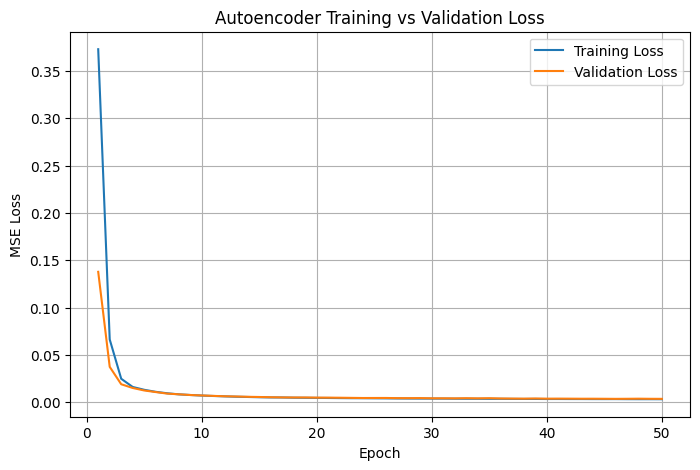

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss")
plt.legend()
plt.grid(True)